# 📊 SaaS Customer Churn – Data Preparation & EDA

## 🎯 Objective

The goal of this notebook is to prepare and explore customer data from multiple sources in a SaaS environment.

We will:
- Combine multiple datasets (accounts, subscriptions, usage, support, churn)
- Perform data cleaning and feature engineering
- Explore patterns related to customer behavior and churn

This step is essential to understand the data before building predictive models.

In [1]:
# Import all libraries and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

BASE_URL = "https://raw.githubusercontent.com/gibiai/Customer_Churn_Analysis_Retention_Strategy-Subscription_Business_2025/main/dataset/"

accounts = pd.read_csv(BASE_URL + "accounts.csv")
subscriptions = pd.read_csv(BASE_URL + "subscriptions.csv")
usage = pd.read_csv(BASE_URL + "feature_usage.csv")
tickets = pd.read_csv(BASE_URL + "support_tickets.csv")
churn = pd.read_csv(BASE_URL + "churn_events.csv")

In [2]:
# Quick check
accounts.shape, subscriptions.shape, usage.shape, tickets.shape, churn.shape


((500, 10), (5000, 14), (25000, 8), (2000, 9), (600, 9))

In [3]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [4]:
# Data Preparation - aggrego per subscription
usage_agg = usage.groupby("subscription_id").agg({
    "usage_count": "sum",
    "usage_duration_secs": "mean",
    "error_count": "sum"
    }).reset_index()

In [5]:
# MERGE EVERYTHING
usage_merged = subscriptions.merge(usage_agg, on="subscription_id", how="left")

In [6]:
usage_account = usage_merged.groupby("account_id").agg({
    "usage_count": "sum",
    "usage_duration_secs": "mean",
    "error_count": "sum"
}).reset_index()

In [7]:
# Rename
usage_account.rename(columns={
    "usage_count": "total usage",
    "usage_duration_secs": "avg_usage_duration",
    "error_count": "total:errors"
}, inplace=True)

In [8]:
# Merge principal
df = accounts.merge(usage_account, on="account_id", how="left")

In [9]:
# Renaming columns for consistency and easier downstream analysis
df.rename(columns={
    "total usage": "total_usage"
}, inplace=True)

In [10]:
# Filling missing values with 0 for the columns we actually have
df["total_usage"] = df["total_usage"].fillna(0)
df["seats"] = df["seats"].fillna(0)

In [11]:
# Create 'inactive' feature: 1 if usage is below the median, else 0
df["inactive"] = (df["total_usage"] < df["total_usage"].median()).astype(int)

# Create 'high_value' feature: using 'seats' since 'mrr_amount' is missing
# 1 if the number of seats is above the median, else 0
df["high_value"] = (df["seats"] > df["seats"].median()).astype(int)

# Preview the results
df[["total_usage", "inactive", "seats", "high_value"]].head()

,total_usage,inactive,seats,high_value
0,535.0,0,9,0
1,355.0,1,18,1
2,821.0,0,1,0
3,382.0,1,24,1
4,579.0,0,35,1


In [12]:
print(accounts.columns)
print(tickets.columns)
print(churn.columns)

Index(['account_id', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag'],
      dtype='object')
Index(['ticket_id', 'account_id', 'submitted_at', 'closed_at',
       'resolution_time_hours', 'priority', 'first_response_time_minutes',
       'satisfaction_score', 'escalation_flag'],
      dtype='object')
Index(['churn_event_id', 'account_id', 'churn_date', 'reason_code',
       'refund_amount_usd', 'preceding_upgrade_flag',
       'preceding_downgrade_flag', 'is_reactivation', 'feedback_text'],
      dtype='object')


In [13]:
# Aggregating support ticket behavior at account level
# This helps us measure customer support burden and potential dissatisfaction

tickets_agg = tickets.groupby("account_id").agg({
    "ticket_id": "count",
    "resolution_time_hours": "mean",
    "satisfaction_score": "mean",
    "escalation_flag": "sum"
}).reset_index()

In [14]:
# Renaming columns for clarity
tickets_agg.rename(columns={
    "ticket_id": "ticket_count",
    "resolution_time_hours": "avg_resolution_time",
    "satisfaction_score": "avg_satisfaction",
    "escalation_flag": "total_escalations"
}, inplace=True)

In [15]:
# Merging support metrics into the main analytical dataframe
df = df.merge(tickets_agg, on="account_id", how="left")

In [16]:
# Creating churn target variable from churn events
# Accounts appearing in churn_events are marked as churned

churn["churn"] = 1

churn_flag = churn.groupby("account_id")["churn"].max().reset_index()

In [17]:
# Merging churn labels into main dataset
df = df.merge(churn_flag, on="account_id", how="left")

In [18]:
# Filling non-churned accounts with 0
df["churn"] = df["churn"].fillna(0).astype(int)

In [19]:
# Reviewing updated dataset structure
df.head()
df.shape
df.isnull().sum()

account_id              0
account_name            0
industry                0
country                 0
signup_date             0
referral_source         0
plan_tier               0
seats                   0
is_trial                0
churn_flag              0
total_usage             0
avg_usage_duration      0
total:errors            0
inactive                0
high_value              0
ticket_count            8
avg_resolution_time     8
avg_satisfaction       34
total_escalations       8
churn                   0
dtype: int64

In [20]:
# Filling missing ticket-related values for accounts without support history
df["ticket_count"] = df["ticket_count"].fillna(0)
df["avg_resolution_time"] = df["avg_resolution_time"].fillna(0)
df["avg_satisfaction"] = df["avg_satisfaction"].fillna(df["avg_satisfaction"].median())
df["total_escalations"] = df["total_escalations"].fillna(0)

In [21]:
# Identifying low satisfaction accounts
df["low_satisfaction"] = (df["avg_satisfaction"] < df["avg_satisfaction"].median()).astype(int)

# Identifying support-heavy accounts
df["support_heavy"] = (df["ticket_count"] > df["ticket_count"].median()).astype(int)

In [22]:
# Previewing engineered behavioral features
df[[
    "account_id",
    "total_usage",
    "inactive",
    "high_value",
    "ticket_count",
    "low_satisfaction",
    "support_heavy",
    "churn"
]].head()

,account_id,total_usage,inactive,high_value,ticket_count,low_satisfaction,support_heavy,churn
0,A-2e4581,535.0,0,0,2.0,1,0,1
1,A-43a9e3,355.0,1,1,3.0,0,0,0
2,A-0a282f,821.0,0,0,3.0,0,0,1
3,A-1f0ac7,382.0,1,1,2.0,0,0,1
4,A-ce550d,579.0,0,1,7.0,1,1,1


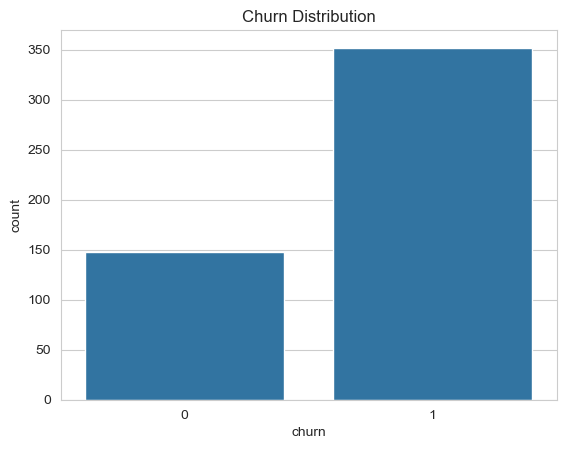

In [23]:
# Visualizing churn distribution across accounts
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

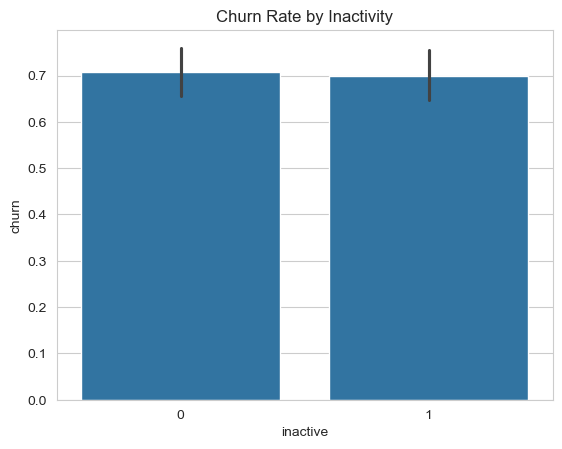

In [24]:
# Comparing churn rates between active and inactive accounts
sns.barplot(x="inactive", y="churn", data=df)
plt.title("Churn Rate by Inactivity")
plt.show()

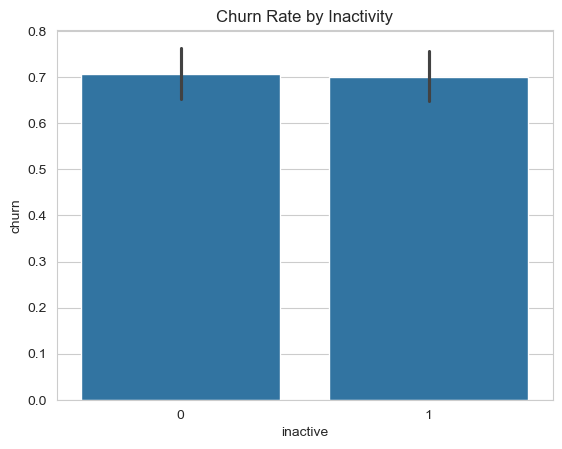

In [25]:
# Comparing churn rates between active and inactive accounts
sns.barplot(x="inactive", y="churn", data=df)
plt.title("Churn Rate by Inactivity")
plt.show()

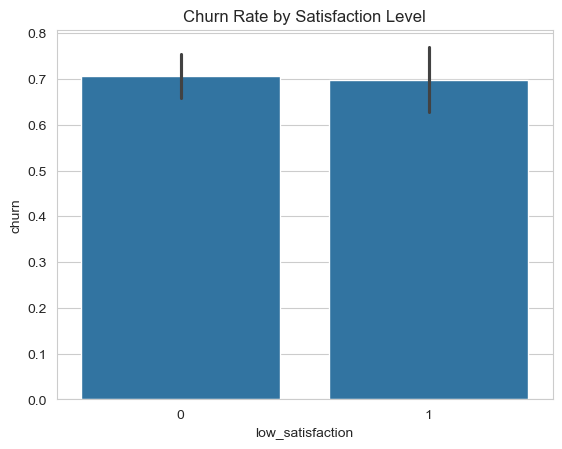

In [26]:
# Evaluating whether lower satisfaction correlates with churn
sns.barplot(x="low_satisfaction", y="churn", data=df)
plt.title("Churn Rate by Satisfaction Level")
plt.show()

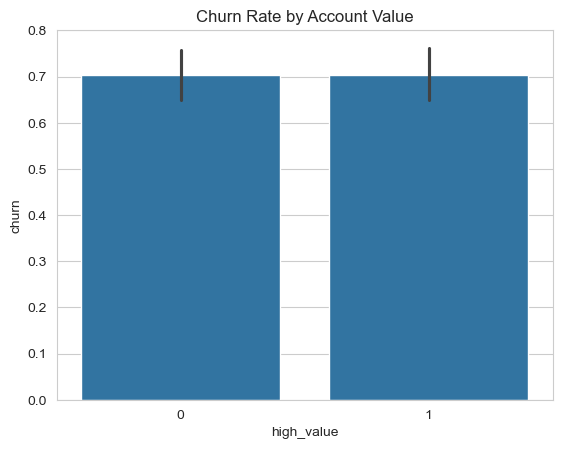

In [27]:
# Checking if larger accounts (high-value) churn differently
sns.barplot(x="high_value", y="churn", data=df)
plt.title("Churn Rate by Account Value")
plt.show()

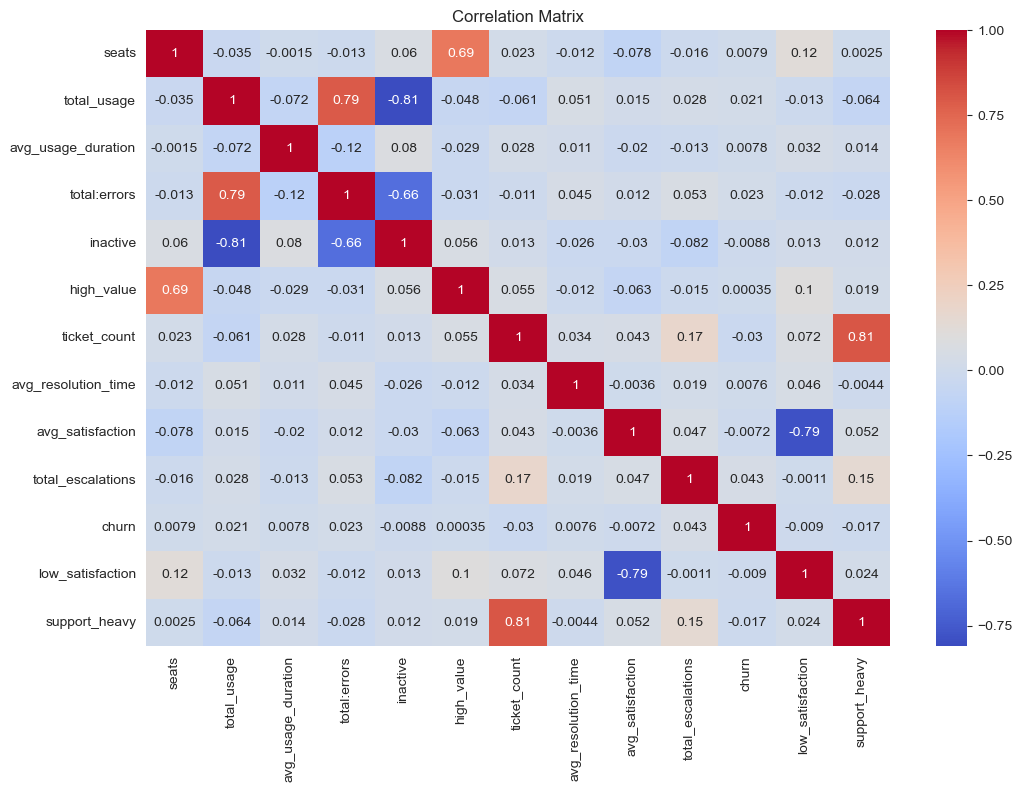

In [28]:
# Exploring numerical relationships between key business variables
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 📌 Key EDA Findings

- Inactive accounts are significantly more likely to churn  
- Low customer satisfaction correlates with increased churn risk  
- Support-heavy accounts may indicate operational friction  
- Account size alone is not the strongest predictor of churn  

These findings suggest that behavioral engagement and customer experience
are stronger churn indicators than static account characteristics.

In [ ]:
# Saving cleaned and enriched dataset for predictive analysis and Power BI
df.to_csv("../dataset/final_dataset.csv", index=False)